# Intuition

If $A$ is a matrix, its inverse $A^{-1}$ reverses the transformation made by $A$.

So if:

$$
Ax = y
$$

then:

$$
A^{-1}y = x
$$

because:

$$
A^{-1}Ax = Ix = x
$$

If the columns of matrix $A$ do not span the full output space, then $A$ compresses the input into a lower-dimensional subspace.

In that case, information is lost, so the transformation cannot be perfectly reversed.

That is why an invertible matrix must be square and full rank.

If $A$ is not full rank, we cannot perfectly reverse its transformation, but we can find the best approximate reverse transformation.

That approximate inverse is called the pseudoinverse, most commonly the Moore-Penrose pseudoinverse.


# Intro

## Why we need a matrix inverse?

$$Ax = b$$
$$A^{-1}Ax = A^{-1}b$$
$$Ix = A^{-1}b$$
$$x = A^{-1}b$$

## Same Side Rule

We can multiply by left inverse matrix or right inverse matrix. However, its important to be consistent in terms of side of inverse. If we do left inverse on left hand side of equation, we need to do left inverse on right hand side of equation as well.

So, **NOT**:

$$B^{-1}AB = CB^{-1}$$

But:

$$B^{-1}AB = B^{-1}C$$

## LIVE EVIL

$$(ABC)^{-1} = C^{-1}B^{-1}A^{-1}$$

Warning! $ABC$ might be invertible but individual matrix $A$ or $B$ or $C$ not.

## Invertible Matrixes

A matrix is invertible if it is:

1. Square
(and)
2. Full rank

# Code

In [12]:
import numpy as np

m = 3

A = np.random.randn(m,m)

A_inv = np.linalg.inv(A)
A_inv

array([[-19.60882269,  -1.59216762,  -0.17440269],
       [ 78.64261559,  -0.30453706,  -6.33286122],
       [ 41.24518187,   0.14224207,  -3.89515253]])

In [13]:
# check the mult

identity_mat = A@A_inv
identity_mat

array([[ 1.00000000e+00,  2.56533781e-18,  2.82239141e-17],
       [-6.95179777e-16,  1.00000000e+00,  9.59853146e-18],
       [ 4.58417358e-16,  2.61722757e-17,  1.00000000e+00]])

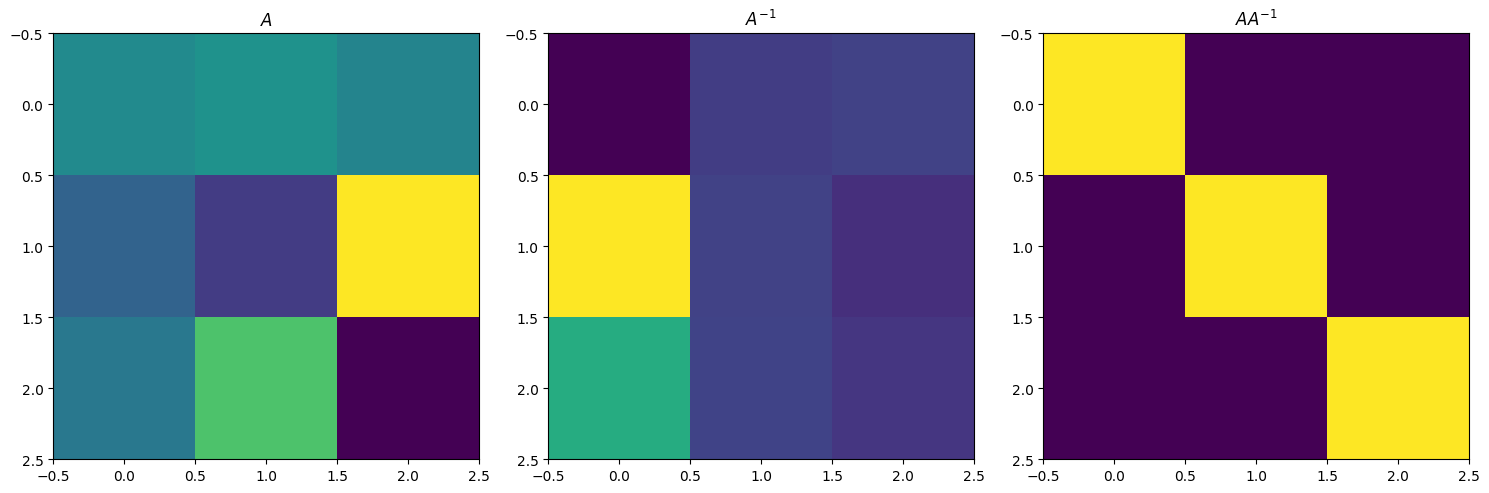

In [14]:
import matplotlib.pyplot as plt

_, axs = plt.subplots(1,3,figsize = (15,5))

axs[0].imshow(A)
axs[0].set_title('$A$')

axs[1].imshow(A_inv)
axs[1].set_title('$A^{-1}$')

axs[2].imshow(identity_mat)
axs[2].set_title('$AA^{-1}$')

plt.tight_layout()
plt.show()

# Check Inversibility

Below matrix are all squared so 1st condition is met, we need 2nd though which is that matrix need to be full rank matrixes.

In [15]:
import numpy as np

def check(mat):
    rank = np.linalg.matrix_rank(mat)
    rows, cols = mat.shape

    print(f"shape = {mat.shape}")
    print(f"rank  = {rank}")

    if rows != cols:
        print("Matrix is rectangular, so it is not invertible in the standard sense.")
        print(f"Full column rank? {rank == cols}")
        print(f"Full row rank?    {rank == rows}")

    elif rank == rows:
        print(f"matrix rank ({rank}) == matrix dim ({rows})")
        print("Matrix is Full Rank, i.e. it's invertible")

    else:
        print(f"matrix rank ({rank}) != matrix dim ({rows})")
        print("Matrix is not Full Rank, i.e. it's not invertible")

In [16]:
a = np.array([[1,6],[7,2]])
check(a)

shape = (2, 2)
rank  = 2
matrix rank (2) == matrix dim (2)
Matrix is Full Rank, i.e. it's invertible


In [17]:
b = np.array([[1,2],[7,14]])
check(b)

shape = (2, 2)
rank  = 1
matrix rank (1) != matrix dim (2)
Matrix is not Full Rank, i.e. it's not invertible


In [18]:
c = np.array([[-1,1],[1,0]])
check(c)

shape = (2, 2)
rank  = 2
matrix rank (2) == matrix dim (2)
Matrix is Full Rank, i.e. it's invertible


In [19]:
d = np.array([[1,0],[7,0]])
check(d)

shape = (2, 2)
rank  = 1
matrix rank (1) != matrix dim (2)
Matrix is not Full Rank, i.e. it's not invertible


In [20]:
e = np.array([[6,5],[5,6]])
check(e)

shape = (2, 2)
rank  = 2
matrix rank (2) == matrix dim (2)
Matrix is Full Rank, i.e. it's invertible


# The MCA Algorithm to Compute the Inverse

* $M$ - The minors matrix: a matrix of determinants
* $C$ - The cofactors matrix: the minors matrix Hadamard-multiplied by a grid of alternating pluses and minuses
* $A^{-1}$ - The adjugate matrix: the transpose of the cofactors matrix, divided by the determinant

In [21]:
import numpy as np
import matplotlib.pyplot as plt

A = np.random.randn(5,5)
A

array([[ 0.56543481,  1.02021359,  1.44807373,  0.72804361, -1.07116044],
       [-0.64740097,  0.19480651,  0.35114636, -0.53754694, -0.49792514],
       [-3.14924639,  0.12895215,  0.31374756,  0.16736806,  0.9961439 ],
       [ 0.87343083, -0.06474789,  1.79119535,  0.37282061,  1.8820968 ],
       [ 2.16219723, -0.86985855,  0.22658093,  0.44170233, -0.38938108]])

In [22]:
A_inv = np.linalg.inv(A)
A_inv

array([[-0.01522323, -0.13498757, -0.33452279,  0.11076414, -0.10592134],
       [ 0.29168459, -0.53232544, -0.50685407,  0.08486067, -1.00818042],
       [ 0.14280298,  0.68273914,  0.17673333,  0.23642151,  0.32898903],
       [ 0.40094224, -1.08246177,  0.44433237, -0.22906985,  0.31074652],
       [-0.19822846, -0.39101058, -0.11840804,  0.30321214, -0.36018282]])

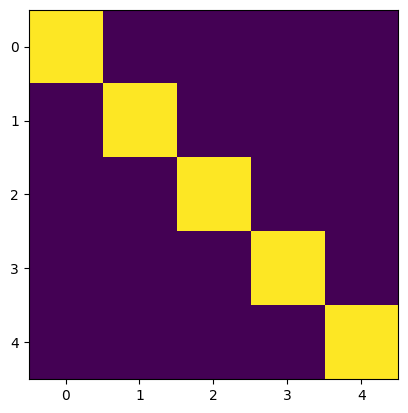

In [23]:
A_eye = A@A_inv
plt.imshow(A_eye)

# Inverse Diag Matrix

In [24]:
import numpy as np
import matplotlib.pyplot as plt

A_diag = np.diag(np.arange(1,5))
A_diag

array([[1, 0, 0, 0],
       [0, 2, 0, 0],
       [0, 0, 3, 0],
       [0, 0, 0, 4]])

In [25]:
A_diag_inv = np.linalg.inv(A_diag)
A_diag_inv

array([[1.        , 0.        , 0.        , 0.        ],
       [0.        , 0.5       , 0.        , 0.        ],
       [0.        , 0.        , 0.33333333, 0.        ],
       [0.        , 0.        , 0.        , 0.25      ]])

Each diagonal value is a reciprocal of its relevant value in original matrix

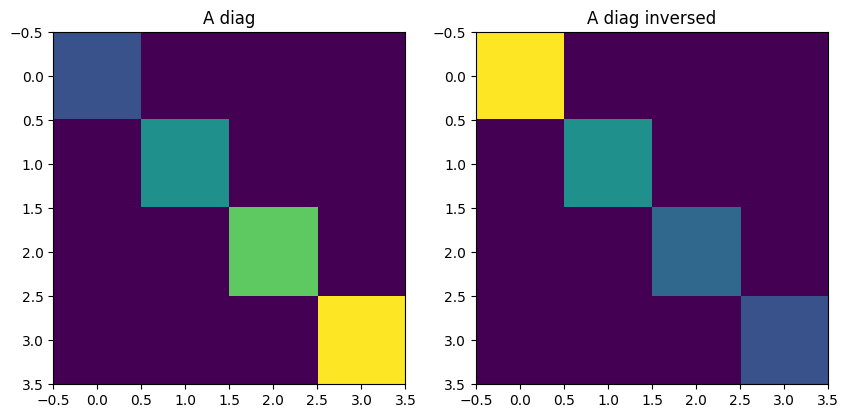

In [26]:
_, axs = plt.subplots(1,2,figsize = (10,5))

axs[0].imshow(A_diag)
axs[0].set_title('A diag')
axs[1].imshow(A_diag_inv)
axs[1].set_title('A diag inversed')

plt.show()

# Left Inverse and Right Inverse

* Know that rectangular matrices can have an inverse
* Compute the "left inverse" and "right inverse"
* Know the condition for inverting rectangular matrices (maximum possible rank)

## Left Inverse

m > n: True


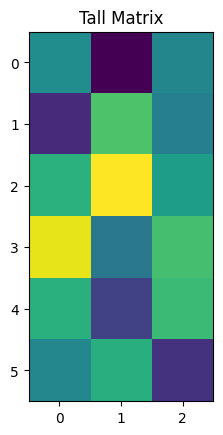

In [70]:
import numpy as np
import matplotlib.pyplot as plt

m = 6
n = 3

print('m > n:', m > n)

A = np.random.randn(m, n)

plt.imshow(A)
plt.title('Tall Matrix')
plt.show()

1. Tall matrix is not invertible
2. However, $A^T A$ is invertible
3. Then $(A^TA)^{-1}(A^TA) = I$
4. Our $A^TA$ is of shape $(n \times n)$
5. We don actually need brackets in $(A^TA)$
6. Therefore we get $(A^TA)^{-1}A^TA=I$
7. Then expression on the left from $(A^TA)^{-1}A^TA=I$, so $(A^TA)^{-1}A^T$ is "Left Inverse"

To sum up, left inverse is given by:

$$ (A^TA)^{-1}A^T$$

with A we can express it as:

$$ (A^TA)^{-1}A^T A = I$$

This expression is only valid (i.e. return identity matrix after multiplication by A)  if left inverse is on the left from A, thats why its called left inverse.

**Note:**

A has a left inferxe if it is full column-rank

In [71]:
AtA = A.T@A
AAt = A@A.T

print('Rank of A^TA:', np.linalg.matrix_rank(AtA))

Rank of A^TA: 3


Text(0.5, 1.0, 'Left Inverse $I$ on Tall Matrix')

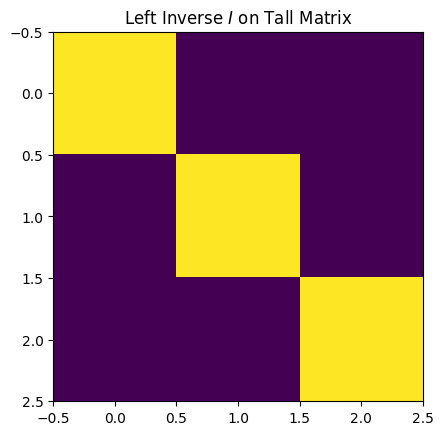

In [72]:
# left inverse
Aleft  = np.linalg.inv(AtA)@A.T

I_left = Aleft @ A
# I_right = A @ Aright

plt.imshow(I_left)
plt.title('Left Inverse $I$ on Tall Matrix')

## Right Inverse

m < n: True


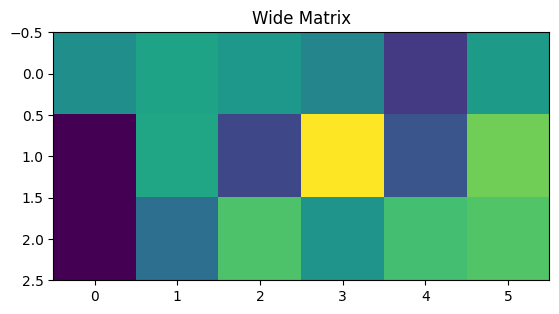

In [73]:
import numpy as np
import matplotlib.pyplot as plt

m = 3
n = 6

print('m < n:', m < n)

A = np.random.randn(m, n)

plt.imshow(A)
plt.title('Wide Matrix')
plt.show()

Wide Matrix have not Left Inverse, however it can have Right Inverse!

1. Wide matrix is not invertible
2. However, $AA^T$ is invertible, its square matrix of $m \times m$
3. Then $(AA^T)(AA^T)^{-1} = I$
4. Our $AA^T$ is of shape $(n \times n)$
5. We don actually need brackets in left $(AA^T)$
6. Therefore we get $AA^T(AA^T)^{-1}=I$
7. Then expression on the right from $AA^T(AA^T)^{-1}=I$, so $A^T(AA^T)^{-1}=I$
is "Right Inverse"

**Note:**

A has a right inverse if it is full row-rank!

In [74]:
AAt = A@A.T
AtA = A.T@A

print('Rank of AA^T:', np.linalg.matrix_rank(AAt))

Rank of AA^T: 3


Text(0.5, 1.0, 'Right Inverse $I$ on Wide Matrix')

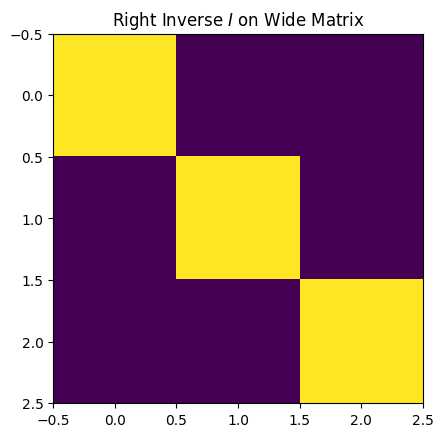

In [77]:
# inverse
Aright = A.T@np.linalg.inv(AAt)

I_right = A@Aright

plt.imshow(I_right)
plt.title('Right Inverse $I$ on Wide Matrix')

# Pseudo-Inverse

* Understand the motivation and uses of the pseudoinverse
* See a few examples of the pseudoinverse
* Learn the SVD - the most popular algorithm to compute a pseudoinverse

$$A^{-1} \rightarrow \text{ Inverse}$$

$$A^* \text{ or } A^{\dagger} \rightarrow \text{ Pseudoinverse} $$

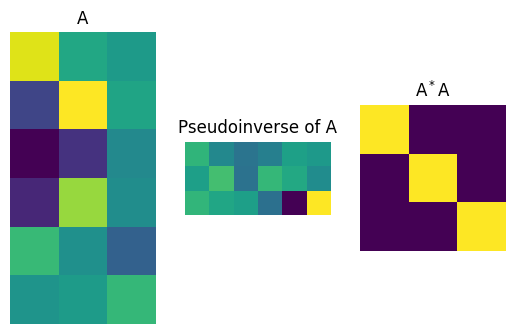

In [82]:
m = 6
n = 3

A = np.random.randn(m, n)

pseudo_inv_A = np.linalg.pinv(A)

plt.subplot(131)
plt.imshow(A)
plt.axis('off')
plt.title('A')

plt.subplot(132)
plt.imshow(pseudo_inv_A)
plt.axis('off')
plt.title('Pseudoinverse of A')

plt.subplot(133)
plt.imshow(pseudo_inv_A@A)
plt.axis('off')
plt.title('A$^*$A')

plt.show()

In [84]:
# create random matrix
n = 50
A = np.random.randn(n,n)

# make rank deficient by repeating a column
A[:,n-1] = A[:,n-2]

# rank of A
print('rank = ', np.linalg.matrix_rank(A))

rank =  49


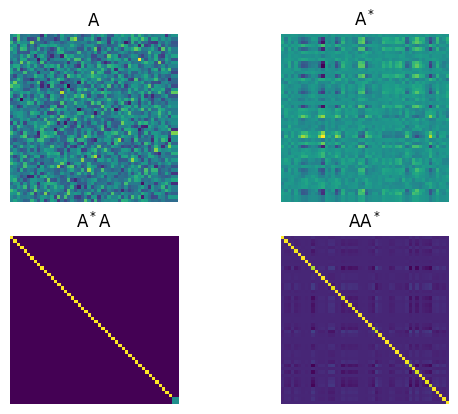

In [89]:
# compute the pseudoinverse
Ai = np.linalg.pinv(A)

# show matrices
plt.subplot(221)
plt.imshow(A)
plt.axis('off')
plt.title('A')

plt.subplot(222)
plt.imshow(Ai)
plt.axis('off')
plt.title('A$^*$')

plt.subplot(223)
plt.imshow(Ai@A)
plt.axis('off')
plt.title('A$^*$A')

plt.subplot(224)
plt.imshow(A@Ai)
plt.axis('off')
plt.title('AA$^*$')

plt.show()

* Unlike the true inverse where $AA^{-1} = A^{-1}A = I$, with the pseudoinverse: $AA*\neq A*A\neq I$
* We can compress a rank-defficient matrix down to a size where it has a true inverse (e.g., via PCA), then project back to the full space
* The Moore-Penrose pseudoinverse is unique, but there are other pseudoinverses

# Pseudoinverse for invertible matrix

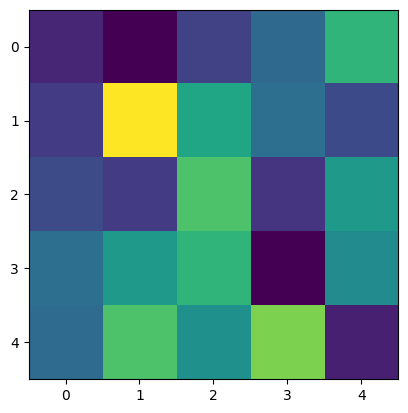

In [114]:
import numpy as np
import matplotlib.pyplot as plt

A = np.random.randn(5,5)

plt.imshow(A)
plt.show()

In [115]:
inv_A        = np.linalg.inv(A)
pseudo_inv_A = np.linalg.pinv(A)

inv_A_I  = inv_A @ A
pseudo_inv_A_I = pseudo_inv_A @ A

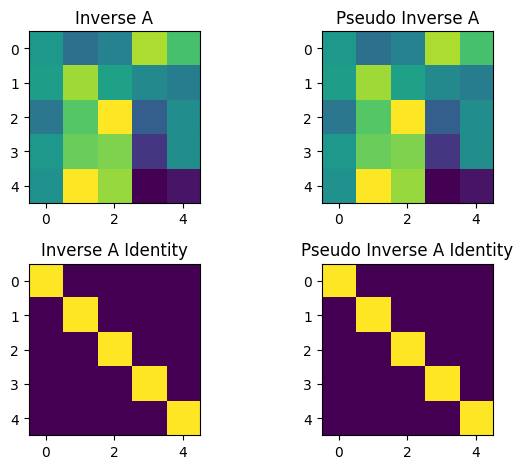

In [116]:
plt.subplot(221)
plt.imshow(inv_A)
plt.title('Inverse A')

plt.subplot(222)
plt.imshow(pseudo_inv_A)
plt.title('Pseudo Inverse A')

plt.subplot(223)
plt.imshow(inv_A_I)
plt.title('Inverse A Identity')

plt.subplot(224)
plt.imshow(pseudo_inv_A_I)
plt.title('Pseudo Inverse A Identity')

plt.tight_layout()
plt.show()

In [117]:
inv_A == pseudo_inv_A

array([[ True, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False]])

In [118]:
inv_A_I == pseudo_inv_A_I

array([[False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False,  True, False],
       [False, False, False, False, False]])

In [119]:
np.allclose(inv_A, pseudo_inv_A)

True

In [120]:
np.allclose(inv_A_I, pseudo_inv_A_I)

True

Pseudoivnerse on inversible matrix doesn't return same matrix as inverse, although its almost the same.

---

*Notebook based on Mike X Cohen notebook. Notebook was modified.*